# NB_08A — Context Risk Overlay exploratorio


---

## Objetivo del notebook

Este notebook incorpora una capa adicional de análisis contextual 

La pregunta no es:

> ¿Las noticias predicen el mercado?

La pregunta correcta es:

> ¿El contexto de mercado/riesgo permite modular la exposición de una estrategia técnica + ML para reducir pérdidas o mejorar la robustez?

---

## dentro del TFM

Hasta ahora se validó:

```text
NB_05  → Dataset supervisado
NB_06  → Modelos ML y validación temporal
NB_06B → Thresholds, ranking y deciles
NB_07  → Ablación económica signal-level
NB_07B → Backtest event-driven de cartera con scores ML
```

Este notebook agrega una extensión adicional:

```text
NB_08A → Context Risk Overlay basado en variables de régimen ya disponibles
```

No reemplaza el sistema central.  
No reentrena modelos.  
No incorpora FinBERT como regla decisoria.  
Evalúa si las variables de régimen ya embebidas en el dataset permiten crear un filtro contextual de riesgo.

---

## Idea metodológica

El sistema base más sólido hasta ahora fue:

```text
RandomForest_TOP_30
```

El overlay contextual prueba variantes como:

```text
RF_TOP_30 normal
RF_TOP_30 sin señales en riesgo alto
RF_TOP_20 sin señales en riesgo alto
RF_TOP_10 solo alta convicción
RF adaptativo: TOP_30 en riesgo bajo, TOP_20 en riesgo medio, TOP_10 en riesgo alto, pausa en riesgo extremo
```

La lógica financiera es:

> No se intenta predecir el shock fundamental. Se intenta reducir exposición cuando el régimen de mercado muestra estrés.

In [1]:
# ============================================================
# 0. Imports y configuración
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

INITIAL_CAPITAL = 200_000.0
MAX_POSITIONS = 20

BASE_DIR = Path.cwd()

# Rutas esperadas según la estructura JUNIO/
DATASET_PATH = BASE_DIR / "../NB_05/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip"
PREDICTIONS_PATH = BASE_DIR / "../NB_06/outputs_nb06b/predictions_walkforward_nb06b.csv.zip"
AUDIT_PATH = BASE_DIR / "../NB_05/df_nb04b2_v4_signal_trade_audit.csv"

OUTPUT_DIR = BASE_DIR / "outputs_nb08a"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
EQUITY_DIR = FIG_DIR / "equity_curves"
DRAWDOWN_DIR = FIG_DIR / "drawdowns"
YEARLY_DIR = FIG_DIR / "yearly"

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, EQUITY_DIR, DRAWDOWN_DIR, YEARLY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATASET_PATH:", DATASET_PATH, "->", DATASET_PATH.exists())
print("PREDICTIONS_PATH:", PREDICTIONS_PATH, "->", PREDICTIONS_PATH.exists())
print("AUDIT_PATH:", AUDIT_PATH, "->", AUDIT_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

missing = [str(p) for p in [DATASET_PATH, PREDICTIONS_PATH, AUDIT_PATH] if not p.exists()]
if missing:
    raise FileNotFoundError("No se encontraron archivos requeridos: " + " | ".join(missing))

BASE_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_08A
DATASET_PATH: /Users/rbr/TFM_MVP/JUNIO/NB_08A/../NB_05/outputs_nb05/dataset_supervisado_tecnico_v1.csv.zip -> True
PREDICTIONS_PATH: /Users/rbr/TFM_MVP/JUNIO/NB_08A/../NB_06/outputs_nb06b/predictions_walkforward_nb06b.csv.zip -> True
AUDIT_PATH: /Users/rbr/TFM_MVP/JUNIO/NB_08A/../NB_05/df_nb04b2_v4_signal_trade_audit.csv -> True
OUTPUT_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_08A/outputs_nb08a


## 1. Carga de datos

Se cargan tres fuentes:

1. Dataset supervisado de NB_05, con features de régimen.
2. Predicciones walk-forward de NB_06B, con scores Random Forest y otros modelos.
3. Auditoría técnica de señales, con retornos y fechas de salida.

Este notebook se centra en **Random Forest**, porque fue el modelo más consistente en ranking y en backtest event-driven.

In [2]:
# ============================================================
# 1. Carga de datos
# ============================================================

dataset = pd.read_csv(DATASET_PATH)
pred = pd.read_csv(PREDICTIONS_PATH)
audit = pd.read_csv(AUDIT_PATH)

# Normalización de columnas de auditoría
audit = audit.rename(columns={
    "Ticker": "ticker",
    "Year": "signal_year",
    "ret_combo": "outcome_ret_combo",
    "ret_core": "outcome_ret_core",
    "ret_tactical": "outcome_ret_tactical",
})

for df in [dataset, pred, audit]:
    for col in ["signal_date", "entry_date", "core_exit_date", "tactical_exit_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

print("Dataset supervisado:", dataset.shape)
print("Predicciones:", pred.shape)
print("Auditoría:", audit.shape)

display(dataset.head())
display(pred.head())
display(audit.head())

Dataset supervisado: (8155, 76)
Predicciones: (13040, 13)
Auditoría: (8155, 38)


,signal_id,ticker,signal_date,entry_date,signal_year,signal_month,entry_execution_mode,target_combo_positive,target_combo_ge_2pct,target_core_positive,outcome_ret_combo,outcome_ret_core,outcome_ret_tactical,outcome_mfe,outcome_mae,outcome_duration_core_bars,outcome_negative_diagnosis,feat_entry_family,feat_tk_confirmation_status,feat_chikou_diagnostic_status,feat_technical_priority_score,feat_kumo_actual_thickness_pct_signal,feat_volume_rel_signal,feat_stoch_k_entry,feat_stoch_d_entry,feat_stoch_k_minus_d_entry,feat_row_operational_ok,feat_liquidity_ok,feat_precio_sobre_kumo_actual,feat_precio_dentro_kumo_actual,feat_precio_bajo_kumo_actual,feat_kumo_actual_alcista,feat_kumo_futuro_alcista,feat_kumo_alcista_requerido,feat_ha_bullish,feat_ha_bullish_prev1,feat_ha2_bullish,feat_ha2_bullish_sobre_kumo,feat_stoch_cross_up_from_below,feat_stoch_not_extreme_overbought,feat_tenkan_sobre_kijun,feat_tk_cross_up_today,feat_tk_cross_up_recent,feat_chikou_above_close_22ago,feat_chikou_above_high_22ago,feat_chikou_above_kumo_22ago,feat_entry_condition_base,feat_entry_event_new_condition,feat_entry_event_after_cooldown,feat_dollar_volume_ma20,feat_kumo_actual_thickness_abs,feat_kumo_actual_thickness_pct_daily,feat_volume_rel_daily,feat_stoch_k_daily,feat_stoch_d_daily,feat_ret_5d_prior,feat_ret_10d_prior,feat_ret_20d_prior,feat_volatility_20d_prior,feat_dist_close_to_kijun_pct,feat_dist_close_to_tenkan_pct,feat_dist_close_to_kumo_top_pct,feat_dist_close_to_kumo_bottom_pct,feat_stoch_k_minus_d_daily,feat_senkou_a_minus_b_pct,feat_regime_breadth_precio_sobre_kumo,feat_regime_breadth_kumo_actual_alcista,feat_regime_breadth_kumo_futuro_alcista,feat_regime_breadth_ha2_bullish,feat_regime_breadth_tenkan_sobre_kijun,feat_regime_breadth_chikou_sobre_kumo,feat_regime_breadth_entry_events,feat_regime_market_ret_5d_mean,feat_regime_market_ret_20d_mean,feat_regime_market_vol_20d_mean,feat_regime_market_volume_rel_mean
0,1,ALLE,2018-04-16,2018-04-16,2018,4,close_signal,0,0,0,-0.0794,-0.0794,-0.0794,0.0196,-0.1156,8,fallo_sin_recorrido_mfe_menor_2pct,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_parcial_sobre_close_22ago,11.2500,0.0255,1.0127,70.7483,64.1724,6.5759,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,0,1,1,0,1,1,1,1,"47,572,294.4716",1.9743,0.0255,1.0127,70.7483,64.1724,0.0098,0.0256,-0.0059,0.0136,0.0105,0.0033,0.0130,0.0385,6.5759,0.0255,0.3753,0.5283,0.4382,0.5849,0.4151,0.5199,0.0147,0.0236,-0.0196,0.0180,0.8883
1,2,BF-B,2018-04-16,2018-04-16,2018,4,close_signal,0,0,0,-0.0124,-0.0587,0.0339,0.0658,-0.0682,36,tuvo_mfe_5pct_y_trailing_pero_combo_negativo,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.5000,0.0182,1.2991,92.9632,88.9731,3.9901,1,1,1,0,0,1,1,1,1,1,1,1,1,0,1,0,0,1,1,1,1,1,1,"41,706,075.7781",0.8872,0.0182,1.2991,92.9632,88.9731,0.0147,0.0500,0.0345,0.0140,0.0328,0.0141,0.0432,0.0614,3.9901,0.0182,0.3753,0.5283,0.4382,0.5849,0.4151,0.5199,0.0147,0.0236,-0.0196,0.0180,0.8883
2,3,PGR,2018-04-16,2018-04-16,2018,4,close_signal,1,0,0,0.0019,-0.0123,0.0161,0.0630,-0.0463,49,positive_or_flat,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.7500,0.0311,1.4822,62.8572,47.5003,15.3569,1,1,1,0,0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1,"149,993,877.2054",1.4920,0.0311,1.4822,62.8572,47.5003,0.0155,0.0187,-0.0160,0.0123,-0.0004,0.0061,0.0464,0.0775,15.3569,0.0311,0.3753,0.5283,0.4382,0.5849,0.4151,0.5199,0.0147,0.0236,-0.0196,0.0180,0.8883
3,4,TECH,2018-04-16,2018-04-16,2018,4,close_signal,1,1,0,0.0291,-0.0233,0.0815,0.1150,-0.0430,51,positive_or_flat,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_libre_sobre_precio_y_kumo_22ago,9.7500,0.0305,1.0450,78.7651,72.5172,6.2479,1,1,1,0,0,1,1,1,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,"22,954,991.0926",1.0980,0.0305,1.0450,78.7651,72.5172,0.0246,0.0347,0.0118,0.0160,0.0177,0.0205,0.0515,0.0820,6.2479,0.0305,0.3753,0.5283,0.4382,0.5849,0.41

,signal_id,ticker,signal_date,entry_date,signal_year,target_combo_positive,outcome_ret_combo,fold,model,score,pred_fixed_0_50,threshold_optimized_f1,pred_optimized_f1
0,4896,AMT,2023-01-03,2023-01-03,2023,1,0.0230,1,Dummy,1.0000,1,0.5000,1
1,4897,A,2023-01-04,2023-01-04,2023,0,-0.0018,1,Dummy,1.0000,1,0.5000,1
2,4898,ABT,2023-01-04,2023-01-04,2023,0,-0.0310,1,Dummy,1.0000,1,0.5000,1
3,4899,ADI,2023-01-04,2023-01-04,2023,1,0.1004,1,Dummy,1.0000,1,0.5000,1
4,4900,BDX,2023-01-04,2023-01-04,2023,0,-0.0720,1,Dummy,1.0000,1,0.5000,1


,signal_id,ticker,signal_year,signal_date,entry_date,entry_price,entry_execution_mode,entry_family,tk_confirmation_status,chikou_diagnostic_status,technical_priority_score,kumo_actual_thickness_pct,Volume_Rel,Stoch_K_entry,Stoch_D_entry,tactical_exit_date,tactical_exit_price,tactical_exit_reason,core_exit_date,core_exit_price,core_exit_reason,trailing_activated,trailing_activated_date,first_inside_kumo_date,first_below_kumo_date,first_stoch_bearish_date,first_ha2_bearish_date,outcome_ret_tactical,outcome_ret_core,outcome_ret_combo,mfe,mae,mfe_minus_abs_mae,duration_core_bars,duration_tactical_bars,max_high_until_core_exit,min_low_until_core_exit,negative_diagnosis
0,1,ALLE,2018,2018-04-16,2018-04-16,77.3274,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_parcial_sobre_close_22ago,11.2500,0.0255,1.0127,70.7483,64.1724,2018-04-26,71.1861,TACTICAL_EXIT_WITH_CORE_INVALIDATION,2018-04-26,71.1861,CORE_CLOSE_BELOW_KUMO_BOTTOM,False,NaN,2018-04-20,2018-04-26,2018-04-19,2018-04-20,-0.0794,-0.0794,-0.0794,0.0196,-0.1156,-0.0961,8,8,78.8400,68.3872,fallo_sin_recorrido_mfe_menor_2pct
1,2,BF-B,2018,2018-04-16,2018-04-16,48.7357,close_signal,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.5000,0.0182,1.2991,92.9632,88.9731,2018-05-25,50.3857,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-06,45.8747,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-05-23,NaN,2018-06-06,2018-04-17,2018-04-19,0.0339,-0.0587,-0.0124,0.0658,-0.0682,-0.0024,36,29,51.9440,45.4113,tuvo_mfe_5pct_y_trailing_pero_combo_negativo
2,3,PGR,2018,2018-04-16,2018-04-16,48.0361,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.7500,0.0311,1.4822,62.8572,47.5003,2018-06-18,48.8087,TACTICAL_TRAILING_3PCT_gap_open_below_stop,2018-06-25,47.4448,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-18,2018-04-25,2018-06-25,2018-04-18,2018-04-20,0.0161,-0.0123,0.0019,0.0630,-0.0463,0.0167,49,44,51.0635,45.8129,positive_or_flat
3,4,TECH,2018,2018-04-16,2018-04-16,35.9652,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_libre_sobre_precio_y_kumo_22ago,9.7500,0.0305,1.0450,78.7651,72.5172,2018-06-21,38.8970,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-27,35.1287,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-21,2018-05-03,2018-06-27,2018-04-19,2018-04-30,0.0815,-0.0233,0.0291,0.1150,-0.0430,0.0720,51,47,40.1000,34.4204,positive_or_flat
4,5,TKO,2018,2018-04-16,2018-04-16,35.8697,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,11.5000,0.0604,1.4770,98.3573,92.1879,2018-08-08,72.0430,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,2018-08-08,72.0430,MAX_HOLD_OR_DATA_END,False,NaN,NaN,NaN,2018-04-17,2018-06-01,1.0085,1.0085,1.0085,1.1808,-0.0304,1.1504,80,80,78.2242,34.7794,positive_or_flat


## 2. Identificación de variables de contexto

Se seleccionan variables de régimen ya disponibles en el dataset.  
La ventaja de este enfoque es que evita introducir un pipeline nuevo y riesgoso de noticias/NLP, pero permite evaluar contexto de mercado.

Variables esperadas:

```text
feat_regime_market_vol_20d_mean
feat_regime_market_ret_5d_mean
feat_regime_market_ret_20d_mean
feat_regime_market_volume_rel_mean
feat_regime_breadth_precio_sobre_kumo
feat_regime_breadth_chikou_sobre_kumo
feat_regime_breadth_kumo_actual_alcista
feat_regime_breadth_kumo_futuro_alcista
feat_regime_breadth_tenkan_sobre_kijun
feat_regime_breadth_entry_events
```

El notebook detecta automáticamente cuáles existen.

In [3]:
# ============================================================
# 2. Variables de contexto disponibles
# ============================================================

candidate_context_features = [
    "feat_regime_market_vol_20d_mean",
    "feat_regime_market_ret_5d_mean",
    "feat_regime_market_ret_20d_mean",
    "feat_regime_market_volume_rel_mean",
    "feat_regime_breadth_precio_sobre_kumo",
    "feat_regime_breadth_chikou_sobre_kumo",
    "feat_regime_breadth_kumo_actual_alcista",
    "feat_regime_breadth_kumo_futuro_alcista",
    "feat_regime_breadth_tenkan_sobre_kijun",
    "feat_regime_breadth_entry_events",
]

available_context_features = [c for c in candidate_context_features if c in dataset.columns]

print("Variables contextuales disponibles:")
for c in available_context_features:
    print("-", c)

if len(available_context_features) < 3:
    raise ValueError(
        "Hay pocas variables contextuales disponibles. Revisar nombres de columnas en dataset_supervisado_tecnico_v1."
    )

context_summary = dataset[available_context_features].describe(percentiles=[.05, .10, .25, .50, .75, .90, .95]).T
display(context_summary)
context_summary.to_csv(TABLE_DIR / "context_features_descriptive_nb08a.csv")

Variables contextuales disponibles:
- feat_regime_market_vol_20d_mean
- feat_regime_market_ret_5d_mean
- feat_regime_market_ret_20d_mean
- feat_regime_market_volume_rel_mean
- feat_regime_breadth_precio_sobre_kumo
- feat_regime_breadth_chikou_sobre_kumo
- feat_regime_breadth_kumo_actual_alcista
- feat_regime_breadth_kumo_futuro_alcista
- feat_regime_breadth_tenkan_sobre_kijun
- feat_regime_breadth_entry_events


,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max
feat_regime_market_vol_20d_mean,"8,155.0000",0.0173,0.0041,0.0106,0.0123,0.0131,0.0147,0.0163,0.0192,0.0216,0.0262,0.0605
feat_regime_market_ret_5d_mean,"8,155.0000",0.0109,0.0197,-0.1567,-0.0181,-0.0111,0.0008,0.0099,0.0196,0.0333,0.0433,0.0930
feat_regime_market_ret_20d_mean,"8,155.0000",0.0280,0.0350,-0.2837,-0.0287,-0.0148,0.0108,0.0294,0.0455,0.0634,0.0789,0.2216
feat_regime_market_volume_rel_mean,"8,155.0000",1.0624,0.2069,0.2977,0.8399,0.8731,0.9378,1.0214,1.1292,1.2454,1.4390,2.3720
feat_regime_breadth_precio_sobre_kumo,"8,155.0000",0.6216,0.1545,0.0323,0.3340,0.4032,0.5333,0.6485,0.7246,0.7982,0.8417,0.9631
feat_regime_breadth_chikou_sobre_kumo,"8,155.0000",0.6605,0.1499,0.0741,0.3604,0.4444,0.5818,0.6874,0.7691,0.8391,0.8607,0.9529
feat_regime_breadth_kumo_actual_alcista,"8,155.0000",0.6540,0.1681,0.0184,0.3382,0.4294,0.5605,0.6770,0.7807,0.8617,0.8958,0.9570
feat_regime_breadth_kumo_futuro_alcista,"8,155.0000",0.6627,0.1591,0.0185,0.3567,0.4354,0.5776,0.6872,0.7787,0.8557,0.8872,0.9624
feat_regime_breadth_tenkan_sobre_kijun,"8,155.0000",0.6188,0.1740,0.0104,0.2601,0.3827,0.5171,0.6506,0.7419,0.8298,0.8617,0.9795
feat_regime_breadth_entry_events,"8,155.0000",0.0232,0.0197,0.0020,0.0040,0.0060,0.0100,0.0182,0.0293,0.0453,0.0658,0.1098


## 3. Construcción de un Context Risk Score

Se construye un score de riesgo contextual usando variables de régimen.

Criterio:

- mayor volatilidad de mercado → más riesgo;
- retornos recientes de mercado más negativos → más riesgo;
- menor amplitud técnica del mercado → más riesgo;
- volumen relativo elevado → puede indicar estrés o shock;
- exceso de eventos de entrada puede indicar concentración/overcrowding, por lo que se trata como factor de atención.

No se entrena un nuevo modelo.  
Se define un índice interpretable y auditable basado en percentiles del propio dataset.

---

## Nota metodológica

Este índice no pretende capturar “la noticia” directamente.  
Captura la reacción agregada del mercado frente al contexto.

In [4]:
# ============================================================
# 3. Context Risk Score interpretable
# ============================================================

def percentile_rank(s):
    return s.rank(pct=True)

risk = pd.DataFrame(index=dataset.index)
risk["signal_id"] = dataset["signal_id"] if "signal_id" in dataset.columns else np.arange(len(dataset))

# Componentes del riesgo:
# 1. Volatilidad: más alto = más riesgo
if "feat_regime_market_vol_20d_mean" in dataset.columns:
    risk["risk_volatility"] = percentile_rank(dataset["feat_regime_market_vol_20d_mean"])
else:
    risk["risk_volatility"] = np.nan

# 2. Retorno de mercado 5d: más bajo = más riesgo
if "feat_regime_market_ret_5d_mean" in dataset.columns:
    risk["risk_market_ret_5d"] = percentile_rank(-dataset["feat_regime_market_ret_5d_mean"])
else:
    risk["risk_market_ret_5d"] = np.nan

# 3. Retorno de mercado 20d: más bajo = más riesgo
if "feat_regime_market_ret_20d_mean" in dataset.columns:
    risk["risk_market_ret_20d"] = percentile_rank(-dataset["feat_regime_market_ret_20d_mean"])
else:
    risk["risk_market_ret_20d"] = np.nan

# 4. Volumen relativo de mercado: más alto = posible estrés / shock
if "feat_regime_market_volume_rel_mean" in dataset.columns:
    risk["risk_volume_rel"] = percentile_rank(dataset["feat_regime_market_volume_rel_mean"])
else:
    risk["risk_volume_rel"] = np.nan

# 5. Breadth técnico: menor amplitud = más riesgo
breadth_cols = [
    "feat_regime_breadth_precio_sobre_kumo",
    "feat_regime_breadth_chikou_sobre_kumo",
    "feat_regime_breadth_kumo_actual_alcista",
    "feat_regime_breadth_kumo_futuro_alcista",
    "feat_regime_breadth_tenkan_sobre_kijun",
]
available_breadth_cols = [c for c in breadth_cols if c in dataset.columns]

if available_breadth_cols:
    breadth_mean = dataset[available_breadth_cols].mean(axis=1)
    risk["risk_breadth_deterioration"] = percentile_rank(-breadth_mean)
else:
    risk["risk_breadth_deterioration"] = np.nan

# 6. Saturación de señales/eventos: más alto = posible crowding o mercado extendido
if "feat_regime_breadth_entry_events" in dataset.columns:
    risk["risk_entry_event_concentration"] = percentile_rank(dataset["feat_regime_breadth_entry_events"])
else:
    risk["risk_entry_event_concentration"] = np.nan

# Pesos definidos de forma interpretable
component_weights = {
    "risk_volatility": 0.25,
    "risk_market_ret_5d": 0.20,
    "risk_market_ret_20d": 0.15,
    "risk_breadth_deterioration": 0.25,
    "risk_volume_rel": 0.10,
    "risk_entry_event_concentration": 0.05,
}

available_components = [c for c in component_weights if c in risk.columns and risk[c].notna().any()]
weight_sum = sum(component_weights[c] for c in available_components)

risk["context_risk_score"] = 0.0
for c in available_components:
    risk["context_risk_score"] += risk[c].fillna(risk[c].median()) * (component_weights[c] / weight_sum)

# Buckets de riesgo por percentiles
risk["context_risk_bucket"] = pd.qcut(
    risk["context_risk_score"],
    q=[0, 0.50, 0.75, 0.90, 1.00],
    labels=["LOW", "MEDIUM", "HIGH", "EXTREME"],
    duplicates="drop"
)

print("Componentes utilizados:", available_components)
display(risk[["signal_id", "context_risk_score", "context_risk_bucket"] + available_components].head())
display(risk["context_risk_bucket"].value_counts(dropna=False).to_frame("n_signals"))

risk.to_csv(TABLE_DIR / "context_risk_score_nb08a.csv", index=False)

Componentes utilizados: ['risk_volatility', 'risk_market_ret_5d', 'risk_market_ret_20d', 'risk_breadth_deterioration', 'risk_volume_rel', 'risk_entry_event_concentration']


,signal_id,context_risk_score,context_risk_bucket,risk_volatility,risk_market_ret_5d,risk_market_ret_20d,risk_breadth_deterioration,risk_volume_rel,risk_entry_event_concentration
0,1,0.6076,HIGH,0.6682,0.1961,0.9239,0.9154,0.1292,0.4191
1,2,0.6076,HIGH,0.6682,0.1961,0.9239,0.9154,0.1292,0.4191
2,3,0.6076,HIGH,0.6682,0.1961,0.9239,0.9154,0.1292,0.4191
3,4,0.6076,HIGH,0.6682,0.1961,0.9239,0.9154,0.1292,0.4191
4,5,0.6076,HIGH,0.6682,0.1961,0.9239,0.9154,0.1292,0.4191


,n_signals
context_risk_bucket,
LOW,4082
MEDIUM,2034
HIGH,1231
EXTREME,808


## 4. Validación inicial del riesgo contextual

Antes de usar el overlay en cartera, se analiza si el `context_risk_score` tiene relación con la calidad posterior de las señales.

Si el índice tiene sentido, las señales en buckets de mayor riesgo deberían mostrar, en promedio:

- menor success rate;
- menor retorno medio;
- peor retorno mediano;
- mayor dispersión.

In [5]:
# ============================================================
# 4. Relación entre riesgo contextual y outcome
# ============================================================

# Consolidar signal-level dataset con outcome principal
base_signal_cols = ["signal_id"]
for c in ["ticker", "entry_date", "signal_year", "target_combo_positive", "outcome_ret_combo"]:
    if c in dataset.columns:
        base_signal_cols.append(c)

signal_context = dataset[base_signal_cols].copy()
signal_context = signal_context.merge(
    risk[["signal_id", "context_risk_score", "context_risk_bucket"]],
    on="signal_id",
    how="left"
)

# Fallback de outcome si hace falta
if "outcome_ret_combo" not in signal_context.columns:
    if "ret_combo" in dataset.columns:
        signal_context["outcome_ret_combo"] = dataset["ret_combo"]
    else:
        raise ValueError("No se encuentra outcome_ret_combo en dataset.")

if "target_combo_positive" not in signal_context.columns:
    signal_context["target_combo_positive"] = (signal_context["outcome_ret_combo"] > 0).astype(int)

risk_bucket_metrics = (
    signal_context
    .groupby("context_risk_bucket", observed=False)
    .agg(
        n_signals=("signal_id", "count"),
        success_rate=("target_combo_positive", "mean"),
        mean_return=("outcome_ret_combo", "mean"),
        median_return=("outcome_ret_combo", "median"),
        p25_return=("outcome_ret_combo", lambda x: x.quantile(0.25)),
        p75_return=("outcome_ret_combo", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

display(risk_bucket_metrics)
risk_bucket_metrics.to_csv(TABLE_DIR / "risk_bucket_signal_quality_nb08a.csv", index=False)

# Por año
risk_bucket_yearly = (
    signal_context
    .groupby(["signal_year", "context_risk_bucket"], observed=False)
    .agg(
        n_signals=("signal_id", "count"),
        success_rate=("target_combo_positive", "mean"),
        mean_return=("outcome_ret_combo", "mean"),
        median_return=("outcome_ret_combo", "median"),
    )
    .reset_index()
)

display(risk_bucket_yearly)
risk_bucket_yearly.to_csv(TABLE_DIR / "risk_bucket_signal_quality_by_year_nb08a.csv", index=False)

,context_risk_bucket,n_signals,success_rate,mean_return,median_return,p25_return,p75_return
0,LOW,4082,0.4909,0.0120,-0.0018,-0.0586,0.0632
1,MEDIUM,2034,0.5280,0.0221,0.0063,-0.0527,0.0753
2,HIGH,1231,0.5053,0.0169,0.0010,-0.0522,0.0662
3,EXTREME,808,0.4653,0.0121,-0.0103,-0.0640,0.0657


,signal_year,context_risk_bucket,n_signals,success_rate,mean_return,median_return
0,2018,LOW,417,0.3453,-0.0194,-0.0339
1,2018,MEDIUM,201,0.4876,0.0052,-0.0023
2,2018,HIGH,51,0.3922,0.0064,-0.0385
3,2018,EXTREME,72,0.3194,-0.0164,-0.0390
4,2019,LOW,772,0.5078,0.0089,0.0023
5,2019,MEDIUM,208,0.5673,0.0206,0.0198
6,2019,HIGH,139,0.6043,0.0218,0.0193
7,2019,EXTREME,39,0.7692,0.0266,0.0254
8,2020,LOW,754,0.4682,0.0035,-0.0095
9,2020,MEDIUM,301,0.5880,0.0490,0.0226


## 5. Integración con scores Random Forest

Se combina el score de Random Forest con el `context_risk_score`.

La lógica no es crear un modelo nuevo, sino evaluar reglas de gestión:

```text
RF_TOP_30_BASE                 → estrategia ML validada
RF_TOP_30_EXCLUDE_EXTREME      → evita señales en riesgo extremo
RF_TOP_30_EXCLUDE_HIGH_EXTREME → evita señales en riesgo alto y extremo
RF_TOP_20_EXCLUDE_EXTREME      → versión más selectiva
RF_RISK_ADAPTIVE               → cambia TOP según régimen de riesgo
```

El objetivo es determinar si el overlay reduce riesgo sin destruir retorno.

In [6]:
# ============================================================
# 5. Construcción de estrategias contextuales
# ============================================================

rf_pred = pred[pred["model"] == "RandomForest"].copy()

required_cols = ["signal_id", "fold", "score"]
missing_rf = [c for c in required_cols if c not in rf_pred.columns]
if missing_rf:
    raise ValueError(f"Faltan columnas en predicciones RF: {missing_rf}")

rf_pred = rf_pred.merge(
    risk[["signal_id", "context_risk_score", "context_risk_bucket"]],
    on="signal_id",
    how="left"
)

# Función para top por fold
def select_top_pct_by_fold(df, pct, strategy_name, risk_filter=None):
    parts = []
    sub = df.copy()
    if risk_filter is not None:
        sub = sub[risk_filter(sub)].copy()

    for fold, g in sub.groupby("fold"):
        n = max(1, int(np.ceil(len(g) * pct)))
        parts.append(g.sort_values("score", ascending=False).head(n))

    if not parts:
        return pd.DataFrame(columns=list(df.columns) + ["strategy"])

    out = pd.concat(parts, ignore_index=True)
    out["strategy"] = strategy_name
    out["selection_score"] = out["score"]
    return out

strategy_parts = []

# Baseline técnico total para comparación
baseline_all = pred[["signal_id", "fold"]].drop_duplicates().copy()
baseline_all["strategy"] = "BASELINE_TECNICO_ALL"
baseline_all["model"] = "TechnicalBaseline"
baseline_all["score"] = np.nan
baseline_all["selection_score"] = np.nan
baseline_all = baseline_all.merge(
    risk[["signal_id", "context_risk_score", "context_risk_bucket"]],
    on="signal_id",
    how="left"
)
strategy_parts.append(baseline_all)

# RF base
strategy_parts.append(select_top_pct_by_fold(rf_pred, 0.30, "RF_TOP_30_BASE"))
strategy_parts.append(select_top_pct_by_fold(rf_pred, 0.20, "RF_TOP_20_BASE"))
strategy_parts.append(select_top_pct_by_fold(rf_pred, 0.10, "RF_TOP_10_BASE"))

# Filtros contextuales
strategy_parts.append(select_top_pct_by_fold(
    rf_pred, 0.30, "RF_TOP_30_EXCLUDE_EXTREME",
    risk_filter=lambda x: x["context_risk_bucket"].astype(str) != "EXTREME"
))

strategy_parts.append(select_top_pct_by_fold(
    rf_pred, 0.30, "RF_TOP_30_EXCLUDE_HIGH_EXTREME",
    risk_filter=lambda x: ~x["context_risk_bucket"].astype(str).isin(["HIGH", "EXTREME"])
))

strategy_parts.append(select_top_pct_by_fold(
    rf_pred, 0.20, "RF_TOP_20_EXCLUDE_EXTREME",
    risk_filter=lambda x: x["context_risk_bucket"].astype(str) != "EXTREME"
))

strategy_parts.append(select_top_pct_by_fold(
    rf_pred, 0.20, "RF_TOP_20_EXCLUDE_HIGH_EXTREME",
    risk_filter=lambda x: ~x["context_risk_bucket"].astype(str).isin(["HIGH", "EXTREME"])
))

# RF risk adaptive:
# LOW -> candidatos TOP 30
# MEDIUM -> candidatos TOP 20
# HIGH -> candidatos TOP 10
# EXTREME -> pausa, no abrir
adaptive_parts = []
for fold, g in rf_pred.groupby("fold"):
    g = g.copy()
    low = g[g["context_risk_bucket"].astype(str) == "LOW"].sort_values("score", ascending=False)
    med = g[g["context_risk_bucket"].astype(str) == "MEDIUM"].sort_values("score", ascending=False)
    high = g[g["context_risk_bucket"].astype(str) == "HIGH"].sort_values("score", ascending=False)
    # EXTREME se excluye

    # La selección se calcula como porcentaje del fold completo para mantener volumen controlado
    n_fold = len(g)
    n_low = max(1, int(np.ceil(n_fold * 0.30))) if len(low) else 0
    n_med = max(1, int(np.ceil(n_fold * 0.20))) if len(med) else 0
    n_high = max(1, int(np.ceil(n_fold * 0.10))) if len(high) else 0

    adaptive_parts += [
        low.head(min(n_low, len(low))),
        med.head(min(n_med, len(med))),
        high.head(min(n_high, len(high))),
    ]

rf_adaptive = pd.concat([x for x in adaptive_parts if len(x)], ignore_index=True)
rf_adaptive["strategy"] = "RF_RISK_ADAPTIVE"
rf_adaptive["selection_score"] = rf_adaptive["score"]
strategy_parts.append(rf_adaptive)

strategy_signals = pd.concat(strategy_parts, ignore_index=True)
strategy_signals = strategy_signals.sort_values(["strategy", "signal_id"]).drop_duplicates(["strategy", "signal_id"])

display(strategy_signals.groupby("strategy")["signal_id"].nunique().sort_values(ascending=False).to_frame("selected_signals"))
strategy_signals.groupby("strategy")["signal_id"].nunique().to_csv(TABLE_DIR / "strategy_selected_signals_nb08a.csv")

,selected_signals
strategy,
BASELINE_TECNICO_ALL,3260
RF_RISK_ADAPTIVE,1930
RF_TOP_30_BASE,980
RF_TOP_30_EXCLUDE_EXTREME,865
RF_TOP_30_EXCLUDE_HIGH_EXTREME,682
RF_TOP_20_BASE,653
RF_TOP_20_EXCLUDE_EXTREME,576
RF_TOP_20_EXCLUDE_HIGH_EXTREME,454
RF_TOP_10_BASE,327


## 6. Métricas signal-level por estrategia

Antes de simular cartera, se mide la calidad media de las señales seleccionadas por cada regla contextual.

In [7]:
# ============================================================
# 6. Métricas signal-level
# ============================================================

signal_eval = strategy_signals[["strategy", "signal_id", "selection_score", "context_risk_score", "context_risk_bucket"]].merge(
    signal_context[["signal_id", "ticker", "entry_date", "signal_year", "target_combo_positive", "outcome_ret_combo"]],
    on="signal_id",
    how="left"
)

signal_level_metrics = (
    signal_eval
    .groupby("strategy")
    .agg(
        n_signals=("signal_id", "nunique"),
        success_rate=("target_combo_positive", "mean"),
        mean_return=("outcome_ret_combo", "mean"),
        median_return=("outcome_ret_combo", "median"),
        p25_return=("outcome_ret_combo", lambda x: x.quantile(0.25)),
        p75_return=("outcome_ret_combo", lambda x: x.quantile(0.75)),
        avg_context_risk=("context_risk_score", "mean"),
    )
    .reset_index()
)

baseline_sl = signal_level_metrics[signal_level_metrics["strategy"] == "BASELINE_TECNICO_ALL"].iloc[0]
signal_level_metrics["delta_success_vs_baseline"] = signal_level_metrics["success_rate"] - baseline_sl["success_rate"]
signal_level_metrics["delta_mean_return_vs_baseline"] = signal_level_metrics["mean_return"] - baseline_sl["mean_return"]

preferred_order = [
    "BASELINE_TECNICO_ALL",
    "RF_TOP_30_BASE", "RF_TOP_20_BASE", "RF_TOP_10_BASE",
    "RF_TOP_30_EXCLUDE_EXTREME",
    "RF_TOP_30_EXCLUDE_HIGH_EXTREME",
    "RF_TOP_20_EXCLUDE_EXTREME",
    "RF_TOP_20_EXCLUDE_HIGH_EXTREME",
    "RF_RISK_ADAPTIVE",
]
signal_level_metrics["order"] = signal_level_metrics["strategy"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
signal_level_metrics = signal_level_metrics.sort_values(["order", "strategy"]).drop(columns="order").reset_index(drop=True)

display(signal_level_metrics)
signal_level_metrics.to_csv(TABLE_DIR / "signal_level_strategy_metrics_nb08a.csv", index=False)

# Distribución por bucket
strategy_bucket_mix = (
    signal_eval
    .groupby(["strategy", "context_risk_bucket"], observed=False)
    .agg(n_signals=("signal_id", "nunique"))
    .reset_index()
)
strategy_bucket_mix["pct"] = strategy_bucket_mix["n_signals"] / strategy_bucket_mix.groupby("strategy")["n_signals"].transform("sum")
display(strategy_bucket_mix)
strategy_bucket_mix.to_csv(TABLE_DIR / "strategy_bucket_mix_nb08a.csv", index=False)

,strategy,n_signals,success_rate,mean_return,median_return,p25_return,p75_return,avg_context_risk,delta_success_vs_baseline,delta_mean_return_vs_baseline
0,BASELINE_TECNICO_ALL,3260,0.5193,0.0228,0.0044,-0.0543,0.0731,0.5200,0.0000,0.0000
1,RF_TOP_30_BASE,980,0.5949,0.0491,0.0263,-0.0459,0.1048,0.4860,0.0756,0.0263
2,RF_TOP_20_BASE,653,0.6003,0.0536,0.0285,-0.0416,0.1101,0.4673,0.0810,0.0307
3,RF_TOP_10_BASE,327,0.6575,0.0667,0.0402,-0.0294,0.1271,0.4402,0.1382,0.0438
4,RF_TOP_30_EXCLUDE_EXTREME,865,0.5919,0.0476,0.0236,-0.0477,0.1043,0.4626,0.0726,0.0248
5,RF_TOP_30_EXCLUDE_HIGH_EXTREME,682,0.6070,0.0495,0.0285,-0.0459,0.1055,0.4234,0.0877,0.0267
6,RF_TOP_20_EXCLUDE_EXTREME,576,0.5990,0.0533,0.0280,-0.0434,0.1072,0.4414,0.0796,0.0305
7,RF_TOP_20_EXCLUDE_HIGH_EXTREME,454,0.6233,0.0568,0.0338,-0.0404,0.1120,0.4054,0.1040,0.0339
8,RF_RISK_ADAPTIVE,1930,0.5503,0.0315,0.0107,-0.0534,0.0860,0.4833,0.0309,0.0087


,strategy,context_risk_bucket,n_signals,pct
0,BASELINE_TECNICO_ALL,LOW,1488,0.4564
1,BASELINE_TECNICO_ALL,MEDIUM,778,0.2387
2,BASELINE_TECNICO_ALL,HIGH,610,0.1871
3,BASELINE_TECNICO_ALL,EXTREME,384,0.1178
4,RF_RISK_ADAPTIVE,LOW,950,0.4922
5,RF_RISK_ADAPTIVE,MEDIUM,653,0.3383
6,RF_RISK_ADAPTIVE,HIGH,327,0.1694
7,RF_RISK_ADAPTIVE,EXTREME,0,0.0000
8,RF_TOP_10_BASE,LOW,232,0.7095
9,RF_TOP_10_BASE,MEDIUM,35,0.1070


## 7. Backtest event-driven con overlay contextual

Se reutiliza la lógica corregida del NB_07B v2:

- capital inicial 200.000 USD;
- máximo 20 posiciones simultáneas;
- entrada por fecha real;
- salida por `core_exit_date`;
- retorno `outcome_ret_combo`;
- equity event-driven corregida.

La diferencia es que ahora se comparan estrategias con y sin filtro contextual.

In [8]:
# ============================================================
# 7. Preparación de auditoría para backtest
# ============================================================

audit_cols = [
    "signal_id", "ticker", "entry_date", "entry_price",
    "core_exit_date", "tactical_exit_date",
    "outcome_ret_combo", "outcome_ret_core", "outcome_ret_tactical",
    "mfe", "mae", "duration_core_bars", "entry_family",
    "tk_confirmation_status", "chikou_diagnostic_status",
    "technical_priority_score", "kumo_actual_thickness_pct", "Volume_Rel",
    "Stoch_K_entry", "Stoch_D_entry"
]
audit_cols = [c for c in audit_cols if c in audit.columns]

test_signal_base = pred[["signal_id", "ticker", "signal_date", "entry_date", "signal_year", "target_combo_positive"]].drop_duplicates()

signals_bt = test_signal_base.merge(
    audit[audit_cols],
    on=["signal_id", "ticker", "entry_date"],
    how="left",
    suffixes=("", "_audit")
)

signals_bt["ret_combo_for_backtest"] = pd.to_numeric(signals_bt["outcome_ret_combo"], errors="coerce")
signals_bt["exit_date"] = pd.to_datetime(signals_bt["core_exit_date"], errors="coerce")

if "duration_core_bars" in signals_bt.columns:
    fallback_exit = signals_bt["entry_date"] + pd.to_timedelta(signals_bt["duration_core_bars"].fillna(20).clip(lower=1).astype(int), unit="D")
else:
    fallback_exit = signals_bt["entry_date"] + pd.to_timedelta(20, unit="D")

signals_bt["exit_date"] = signals_bt["exit_date"].fillna(fallback_exit)
signals_bt = signals_bt.dropna(subset=["entry_date", "exit_date", "ret_combo_for_backtest"])

bad_dates = signals_bt["exit_date"] < signals_bt["entry_date"]
if bad_dates.any():
    print(f"Advertencia: {bad_dates.sum()} exit_date anteriores a entry_date. Se corrigen a entry_date.")
    signals_bt.loc[bad_dates, "exit_date"] = signals_bt.loc[bad_dates, "entry_date"]

bt_candidates = strategy_signals[["strategy", "model", "signal_id", "selection_score", "context_risk_score", "context_risk_bucket"]].merge(
    signals_bt,
    on="signal_id",
    how="left"
)
bt_candidates = bt_candidates.dropna(subset=["entry_date", "exit_date", "ret_combo_for_backtest"])

print("Candidatos estrategia-señal para backtest:", bt_candidates.shape)
display(bt_candidates.groupby("strategy")["signal_id"].nunique().sort_values(ascending=False).to_frame("selected_signals_bt"))

Candidatos estrategia-señal para backtest: (9727, 30)


,selected_signals_bt
strategy,
BASELINE_TECNICO_ALL,3260
RF_RISK_ADAPTIVE,1930
RF_TOP_30_BASE,980
RF_TOP_30_EXCLUDE_EXTREME,865
RF_TOP_30_EXCLUDE_HIGH_EXTREME,682
RF_TOP_20_BASE,653
RF_TOP_20_EXCLUDE_EXTREME,576
RF_TOP_20_EXCLUDE_HIGH_EXTREME,454
RF_TOP_10_BASE,327


In [9]:
# ============================================================
# 8. Simulador event-driven corregido
# ============================================================

def profit_factor_from_pnl(pnls):
    pnls = pd.Series(pnls).dropna()
    gains = pnls[pnls > 0].sum()
    losses = -pnls[pnls < 0].sum()
    if losses == 0:
        return np.inf if gains > 0 else np.nan
    return gains / losses

def max_drawdown_from_equity(equity):
    s = pd.Series(equity).astype(float)
    if s.empty:
        return np.nan
    return (s / s.cummax() - 1).min()

def simulate_strategy_v2(candidates, strategy_name, initial_capital=200_000.0, max_positions=20):
    df = candidates[candidates["strategy"] == strategy_name].copy()
    if df.empty:
        return None, pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if "technical_priority_score" not in df.columns:
        df["technical_priority_score"] = 0

    df["priority_score"] = df["selection_score"].fillna(df["technical_priority_score"]).fillna(0)
    df = df.sort_values(["entry_date", "priority_score", "signal_id"], ascending=[True, False, True]).reset_index(drop=True)

    cash = initial_capital
    open_positions = {}
    trade_log = []
    skipped_log = []
    equity_records = []

    all_entry_dates = sorted(df["entry_date"].dropna().unique())

    def current_equity():
        return cash + sum(pos["allocation"] for pos in open_positions.values())

    def record(date, event, signal_id=None):
        equity_records.append({
            "date": pd.to_datetime(date),
            "equity": current_equity(),
            "cash": cash,
            "open_alloc": sum(pos["allocation"] for pos in open_positions.values()),
            "n_open": len(open_positions),
            "event": event,
            "signal_id": signal_id,
            "strategy": strategy_name
        })

    record(df["entry_date"].min(), "init", None)

    for entry_date in all_entry_dates:
        entry_date = pd.to_datetime(entry_date)

        # Cerrar primero posiciones vencidas
        to_close = [pid for pid, pos in open_positions.items() if pos["exit_date"] <= entry_date]
        for pid in sorted(to_close):
            pos = open_positions.pop(pid)
            pnl = pos["allocation"] * pos["ret"]
            cash += pos["allocation"] + pnl
            pos_out = pos.copy()
            pos_out["pnl"] = pnl
            pos_out["exit_processed_date"] = pos["exit_date"]
            pos_out["cash_after_exit"] = cash
            trade_log.append(pos_out)
            record(pos["exit_date"], "exit", pos["signal_id"])

        # Entradas del día
        day_candidates = df[df["entry_date"] == entry_date].sort_values(["priority_score", "signal_id"], ascending=[False, True])

        for _, row in day_candidates.iterrows():
            if len(open_positions) >= max_positions:
                skipped_log.append({
                    "strategy": strategy_name,
                    "signal_id": row["signal_id"],
                    "ticker": row["ticker"],
                    "entry_date": entry_date,
                    "context_risk_bucket": row.get("context_risk_bucket", None),
                    "reason": "max_positions_reached"
                })
                continue

            equity_basis = current_equity()
            allocation = min(cash, equity_basis / max_positions)

            if allocation <= 0:
                skipped_log.append({
                    "strategy": strategy_name,
                    "signal_id": row["signal_id"],
                    "ticker": row["ticker"],
                    "entry_date": entry_date,
                    "context_risk_bucket": row.get("context_risk_bucket", None),
                    "reason": "no_cash_available"
                })
                continue

            cash -= allocation
            pid = row["signal_id"]

            open_positions[pid] = {
                "strategy": strategy_name,
                "signal_id": row["signal_id"],
                "ticker": row["ticker"],
                "entry_date": row["entry_date"],
                "exit_date": row["exit_date"],
                "signal_year": row["signal_year"],
                "allocation": allocation,
                "ret": row["ret_combo_for_backtest"],
                "selection_score": row.get("selection_score", np.nan),
                "priority_score": row.get("priority_score", np.nan),
                "context_risk_score": row.get("context_risk_score", np.nan),
                "context_risk_bucket": row.get("context_risk_bucket", None),
                "entry_family": row.get("entry_family", None),
                "tk_confirmation_status": row.get("tk_confirmation_status", None),
                "chikou_diagnostic_status": row.get("chikou_diagnostic_status", None),
            }
            record(entry_date, "entry", row["signal_id"])

    # Cerrar remanentes
    for exit_date in sorted(set(pos["exit_date"] for pos in open_positions.values())):
        to_close = [pid for pid, pos in open_positions.items() if pos["exit_date"] <= exit_date]
        for pid in sorted(to_close):
            pos = open_positions.pop(pid)
            pnl = pos["allocation"] * pos["ret"]
            cash += pos["allocation"] + pnl
            pos_out = pos.copy()
            pos_out["pnl"] = pnl
            pos_out["exit_processed_date"] = pos["exit_date"]
            pos_out["cash_after_exit"] = cash
            trade_log.append(pos_out)
            record(pos["exit_date"], "exit", pos["signal_id"])

    trades = pd.DataFrame(trade_log)
    skipped = pd.DataFrame(skipped_log)
    equity = pd.DataFrame(equity_records).sort_values(["date", "event"]).reset_index(drop=True)

    equity_daily = equity.groupby("date", as_index=False).agg(
        equity=("equity", "last"),
        cash=("cash", "last"),
        open_alloc=("open_alloc", "last"),
        n_open=("n_open", "last")
    )
    equity_daily["strategy"] = strategy_name

    final_capital = equity_daily["equity"].iloc[-1]
    total_return = final_capital / initial_capital - 1

    start_date = df["entry_date"].min()
    end_date = max(df["exit_date"].max(), df["entry_date"].max())
    years = max((end_date - start_date).days / 365.25, 1/365.25)
    cagr = (final_capital / initial_capital) ** (1 / years) - 1 if final_capital > 0 else np.nan

    pnls = trades["pnl"] if "pnl" in trades.columns else pd.Series(dtype=float)
    rets = trades["ret"] if "ret" in trades.columns else pd.Series(dtype=float)

    metrics = {
        "strategy": strategy_name,
        "selected_signals": int(df["signal_id"].nunique()),
        "entered_trades": int(len(trades)),
        "skipped_signals": int(len(skipped)),
        "initial_capital": initial_capital,
        "final_capital": final_capital,
        "total_return": total_return,
        "cagr_approx": cagr,
        "max_drawdown_event": max_drawdown_from_equity(equity_daily["equity"]),
        "win_rate_trades": (rets > 0).mean() if len(rets) else np.nan,
        "mean_trade_return": rets.mean() if len(rets) else np.nan,
        "median_trade_return": rets.median() if len(rets) else np.nan,
        "profit_factor": profit_factor_from_pnl(pnls),
        "avg_context_risk_trades": trades["context_risk_score"].mean() if "context_risk_score" in trades.columns and len(trades) else np.nan,
        "avg_allocation": trades["allocation"].mean() if "allocation" in trades.columns and len(trades) else np.nan,
        "avg_holding_days": ((trades["exit_date"] - trades["entry_date"]).dt.days.mean() if len(trades) else np.nan),
        "period_start": start_date,
        "period_end": end_date,
    }

    return metrics, trades, equity_daily, skipped

## 8. Ejecución de backtests contextuales

Se ejecutan todas las estrategias y se comparan contra el baseline técnico.

In [10]:
# ============================================================
# 9. Ejecutar backtests
# ============================================================

strategy_names = sorted(bt_candidates["strategy"].unique())

metrics_list = []
trades_list = []
equity_list = []
skipped_list = []

for strategy_name in strategy_names:
    metrics, trades, equity, skipped = simulate_strategy_v2(
        bt_candidates,
        strategy_name=strategy_name,
        initial_capital=INITIAL_CAPITAL,
        max_positions=MAX_POSITIONS
    )
    if metrics is not None:
        metrics_list.append(metrics)
        trades_list.append(trades)
        equity_list.append(equity)
        skipped_list.append(skipped)

portfolio_metrics = pd.DataFrame(metrics_list)
portfolio_trades = pd.concat(trades_list, ignore_index=True) if trades_list else pd.DataFrame()
portfolio_equity = pd.concat(equity_list, ignore_index=True) if equity_list else pd.DataFrame()
portfolio_skipped = pd.concat(skipped_list, ignore_index=True) if skipped_list else pd.DataFrame()

portfolio_metrics["order"] = portfolio_metrics["strategy"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
portfolio_metrics = portfolio_metrics.sort_values(["order", "strategy"]).drop(columns="order").reset_index(drop=True)

baseline_row = portfolio_metrics[portfolio_metrics["strategy"] == "BASELINE_TECNICO_ALL"]
if baseline_row.empty:
    raise ValueError("No se encontró baseline técnico.")

baseline = baseline_row.iloc[0]

portfolio_metrics["delta_final_capital_vs_baseline"] = portfolio_metrics["final_capital"] - baseline["final_capital"]
portfolio_metrics["delta_total_return_vs_baseline"] = portfolio_metrics["total_return"] - baseline["total_return"]
portfolio_metrics["delta_drawdown_vs_baseline"] = portfolio_metrics["max_drawdown_event"] - baseline["max_drawdown_event"]
portfolio_metrics["delta_win_rate_vs_baseline"] = portfolio_metrics["win_rate_trades"] - baseline["win_rate_trades"]
portfolio_metrics["trade_reduction_vs_baseline"] = 1 - portfolio_metrics["entered_trades"] / baseline["entered_trades"]

display(portfolio_metrics)

portfolio_metrics.to_csv(TABLE_DIR / "portfolio_context_overlay_metrics_nb08a.csv", index=False)
portfolio_trades.to_csv(OUTPUT_DIR / "portfolio_context_overlay_trades_nb08a.csv", index=False)
portfolio_equity.to_csv(OUTPUT_DIR / "portfolio_context_overlay_equity_nb08a.csv", index=False)
portfolio_skipped.to_csv(OUTPUT_DIR / "portfolio_context_overlay_skipped_nb08a.csv", index=False)

,strategy,selected_signals,entered_trades,skipped_signals,initial_capital,final_capital,total_return,cagr_approx,max_drawdown_event,win_rate_trades,mean_trade_return,median_trade_return,profit_factor,avg_context_risk_trades,avg_allocation,avg_holding_days,period_start,period_end,delta_final_capital_vs_baseline,delta_total_return_vs_baseline,delta_drawdown_vs_baseline,delta_win_rate_vs_baseline,trade_reduction_vs_baseline
0,BASELINE_TECNICO_ALL,3260,332,2928,"200,000.0000","255,653.8760",0.2783,0.0855,-0.0931,0.4819,0.0175,-0.0024,1.4762,0.6085,"10,412.7009",63.9849,2023-01-03,2025-12-31,0.0000,0.0000,0.0000,0.0000,0.0000
1,RF_TOP_30_BASE,980,218,762,"200,000.0000","395,127.3009",0.9756,0.2558,-0.0318,0.6193,0.0695,0.0322,3.7372,0.5757,"12,522.1549",76.5321,2023-01-04,2025-12-31,"139,473.4250",0.6974,0.0613,0.1373,0.3434
2,RF_TOP_20_BASE,653,194,459,"200,000.0000","305,949.5507",0.5297,0.1528,-0.0744,0.5464,0.0481,0.0173,2.6420,0.5350,"11,008.9218",73.7371,2023-01-04,2025-12-31,"50,295.6748",0.2515,0.0188,0.0645,0.4157
3,RF_TOP_10_BASE,327,108,219,"200,000.0000","278,036.8854",0.3902,0.1191,-0.0453,0.5926,0.0673,0.0278,3.2058,0.4929,"10,781.1721",77.6481,2023-01-27,2025-12-31,"22,383.0094",0.1119,0.0479,0.1107,0.6747
4,RF_TOP_30_EXCLUDE_EXTREME,865,206,659,"200,000.0000","362,180.2499",0.8109,0.2197,-0.0282,0.6214,0.0632,0.0293,3.6471,0.5417,"12,116.1227",75.7718,2023-01-04,2025-12-31,"106,526.3740",0.5326,0.0650,0.1394,0.3795
5,RF_TOP_30_EXCLUDE_HIGH_EXTREME,682,180,502,"200,000.0000","342,635.2707",0.7132,0.1977,-0.0293,0.6111,0.0658,0.0278,4.0403,0.4879,"11,609.4544",77.9444,2023-01-06,2025-12-31,"86,981.3948",0.4349,0.0638,0.1292,0.4578
6,RF_TOP_20_EXCLUDE_EXTREME,576,192,384,"200,000.0000","281,665.2584",0.4083,0.1221,-0.0976,0.5104,0.0393,0.0119,2.1736,0.5008,"10,656.9174",71.9479,2023-01-10,2025-12-31,"26,011.3825",0.1301,-0.0045,0.0285,0.4217
7,RF_TOP_20_EXCLUDE_HIGH_EXTREME,454,149,305,"200,000.0000","278,754.4539",0.3938,0.1181,-0.0579,0.5101,0.0489,0.0076,2.3956,0.4487,"10,753.5858",73.9060,2023-01-10,2025-12-31,"23,100.5779",0.1155,0.0352,0.0281,0.5512
8,RF_RISK_ADAPTIVE,1930,271,1659,"200,000.0000","316,899.9585",0.5845,0.1664,-0.0541,0.5424,0.0383,0.0114,2.1602,0.5591,"11,571.4736",70.1845,2023-01-04,2025-12-31,"61,246.0826",0.3062,0.0390,0.0605,0.1837


## 9. Análisis por año y por bucket de riesgo

Se analiza si el overlay:

- mejora o empeora la consistencia anual;
- reduce la entrada en contextos de riesgo alto/extremo;
- concentra la cartera en señales de mejor contexto.

In [11]:
# ============================================================
# 10. Resultados por año y bucket
# ============================================================

if not portfolio_trades.empty:
    portfolio_trades["entry_year"] = pd.to_datetime(portfolio_trades["entry_date"]).dt.year

    yearly = (
        portfolio_trades
        .groupby(["strategy", "entry_year"])
        .agg(
            n_trades=("signal_id", "count"),
            pnl_usd=("pnl", "sum"),
            win_rate=("ret", lambda x: (x > 0).mean()),
            mean_trade_return=("ret", "mean"),
            median_trade_return=("ret", "median"),
            profit_factor=("pnl", profit_factor_from_pnl),
            avg_context_risk=("context_risk_score", "mean"),
        )
        .reset_index()
    )
    yearly.to_csv(TABLE_DIR / "yearly_context_overlay_metrics_nb08a.csv", index=False)
    display(yearly)

    bucket_trades = (
        portfolio_trades
        .groupby(["strategy", "context_risk_bucket"], observed=False)
        .agg(
            n_trades=("signal_id", "count"),
            pnl_usd=("pnl", "sum"),
            win_rate=("ret", lambda x: (x > 0).mean()),
            mean_trade_return=("ret", "mean"),
            median_trade_return=("ret", "median"),
            avg_context_risk=("context_risk_score", "mean"),
        )
        .reset_index()
    )
    bucket_trades.to_csv(TABLE_DIR / "trade_results_by_context_bucket_nb08a.csv", index=False)
    display(bucket_trades)

    key_strategies = [
        "BASELINE_TECNICO_ALL",
        "RF_TOP_30_BASE",
        "RF_TOP_30_EXCLUDE_EXTREME",
        "RF_TOP_30_EXCLUDE_HIGH_EXTREME",
        "RF_RISK_ADAPTIVE",
    ]

    display(Markdown("### Retorno por año — estrategias clave"))
    display(yearly[yearly["strategy"].isin(key_strategies)].pivot(index="entry_year", columns="strategy", values="pnl_usd"))

    display(Markdown("### Win rate por año — estrategias clave"))
    display(yearly[yearly["strategy"].isin(key_strategies)].pivot(index="entry_year", columns="strategy", values="win_rate"))
else:
    print("No hay trades para análisis.")

,strategy,entry_year,n_trades,pnl_usd,win_rate,mean_trade_return,median_trade_return,profit_factor,avg_context_risk
0,BASELINE_TECNICO_ALL,2023,127,"14,839.7269",0.4488,0.0142,-0.0083,1.3282,0.5950
1,BASELINE_TECNICO_ALL,2024,93,"20,702.2036",0.5484,0.0212,0.0132,1.7393,0.5601
2,BASELINE_TECNICO_ALL,2025,112,"20,111.9455",0.4643,0.0180,-0.0078,1.4609,0.6640
3,RF_RISK_ADAPTIVE,2023,102,"29,949.8273",0.5196,0.0312,0.0081,1.8404,0.5602
4,RF_RISK_ADAPTIVE,2024,82,"47,790.2170",0.6463,0.0516,0.0256,2.9794,0.5322
5,RF_RISK_ADAPTIVE,2025,87,"39,159.9142",0.4713,0.0340,-0.0043,1.9557,0.5832
6,RF_TOP_10_BASE,2023,34,"20,454.9771",0.5882,0.0593,0.0305,3.3505,0.3582
7,RF_TOP_10_BASE,2024,22,"-1,792.0731",0.4545,-0.0066,-0.0073,0.8600,0.4921
8,RF_TOP_10_BASE,2025,52,"59,373.9813",0.6538,0.1037,0.0508,5.2779,0.5812
9,RF_TOP_20_BASE,2023,71,"27,705.0474",0.5352,0.0389,0.0147,2.8234,0.4906


,strategy,context_risk_bucket,n_trades,pnl_usd,win_rate,mean_trade_return,median_trade_return,avg_context_risk
0,BASELINE_TECNICO_ALL,EXTREME,80,"22,142.1819",0.5375,0.0292,0.0107,0.7874
1,BASELINE_TECNICO_ALL,HIGH,122,"17,909.3913",0.5082,0.0151,0.0007,0.6521
2,BASELINE_TECNICO_ALL,LOW,65,"10,933.9564",0.4769,0.0163,-0.0026,0.3714
3,BASELINE_TECNICO_ALL,MEDIUM,65,"4,668.3464",0.3692,0.0086,-0.0291,0.5437
4,RF_RISK_ADAPTIVE,HIGH,112,"42,174.5956",0.5625,0.0329,0.0154,0.6505
5,RF_RISK_ADAPTIVE,LOW,51,"34,901.1946",0.6078,0.0581,0.0304,0.3691
6,RF_RISK_ADAPTIVE,MEDIUM,108,"39,824.1683",0.4907,0.0345,-0.0017,0.5540
7,RF_TOP_10_BASE,EXTREME,13,"12,939.2397",0.6923,0.0829,0.1005,0.8367
8,RF_TOP_10_BASE,HIGH,21,"15,039.4213",0.4286,0.0689,-0.0244,0.6434
9,RF_TOP_10_BASE,LOW,57,"35,499.5968",0.6316,0.0594,0.0314,0.3420


### Retorno por año — estrategias clave

strategy,BASELINE_TECNICO_ALL,RF_RISK_ADAPTIVE,RF_TOP_30_BASE,RF_TOP_30_EXCLUDE_EXTREME,RF_TOP_30_EXCLUDE_HIGH_EXTREME
entry_year,,,,,
2023,"14,839.7269","29,949.8273","44,749.8259","37,833.8730","24,470.2635"
2024,"20,702.2036","47,790.2170","43,691.8891","37,870.7103","42,943.0650"
2025,"20,111.9455","39,159.9142","106,685.5860","86,475.6667","75,221.9422"


### Win rate por año — estrategias clave

strategy,BASELINE_TECNICO_ALL,RF_RISK_ADAPTIVE,RF_TOP_30_BASE,RF_TOP_30_EXCLUDE_EXTREME,RF_TOP_30_EXCLUDE_HIGH_EXTREME
entry_year,,,,,
2023,0.4488,0.5196,0.6494,0.6712,0.6061
2024,0.5484,0.6463,0.6349,0.6393,0.7407
2025,0.4643,0.4713,0.5769,0.5556,0.5000


## 10. Gráficos

Se generan gráficos para la memoria:

- calidad signal-level por bucket de riesgo;
- capital final por estrategia;
- drawdown por estrategia;
- equity curves;
- drawdown curves.

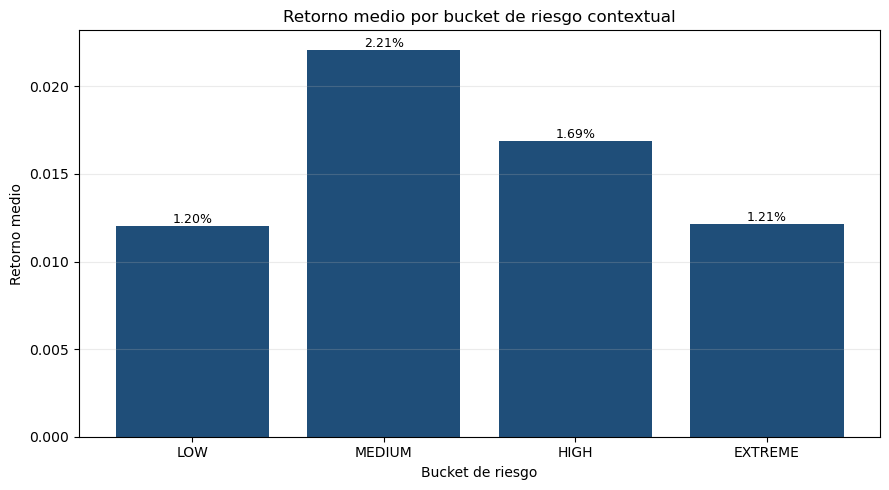

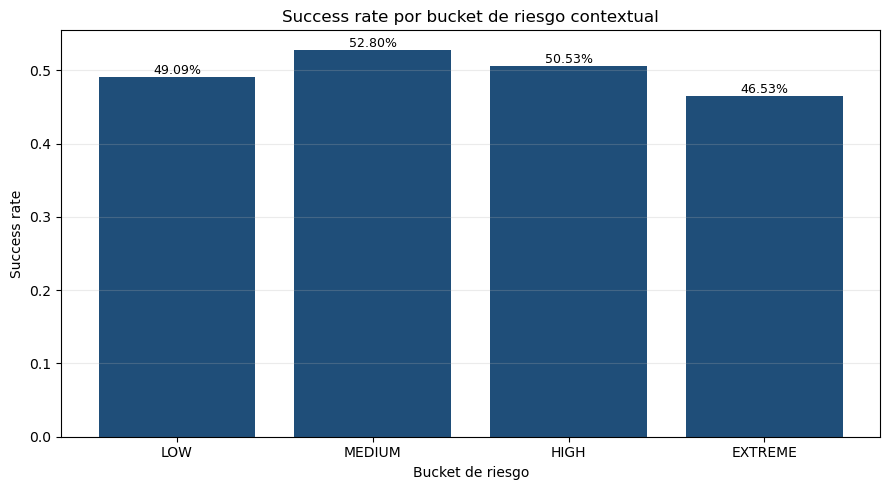

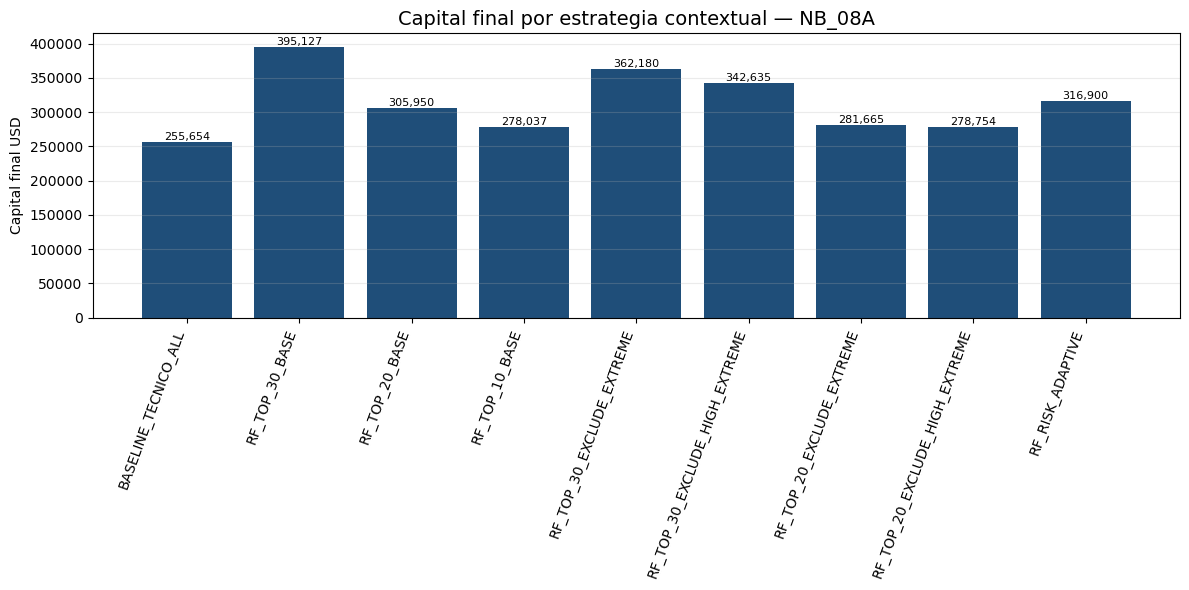

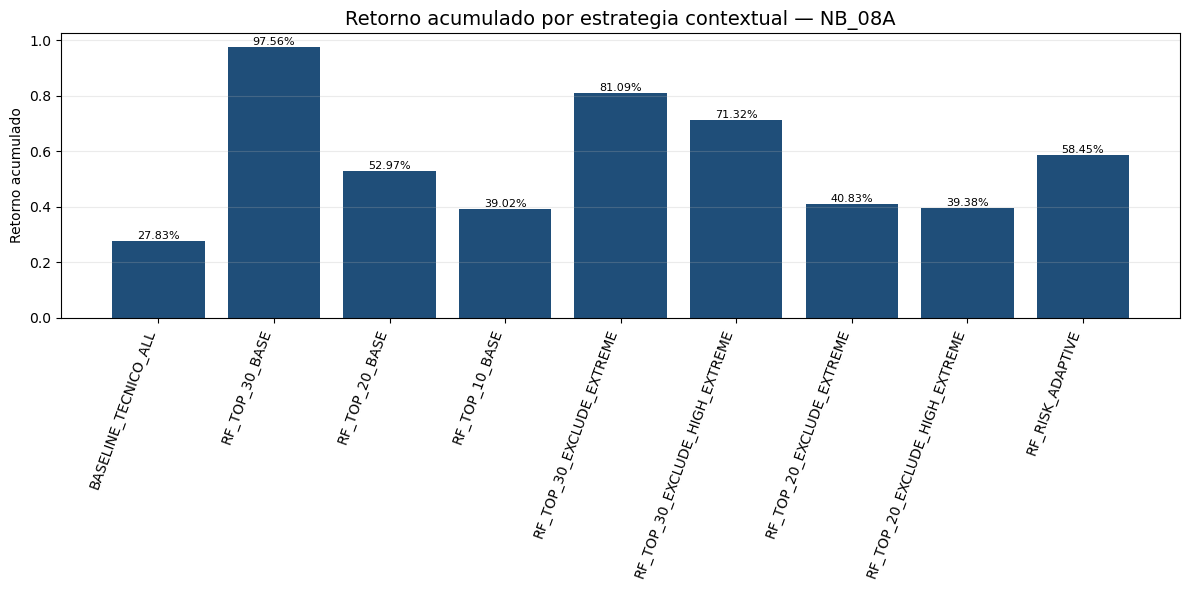

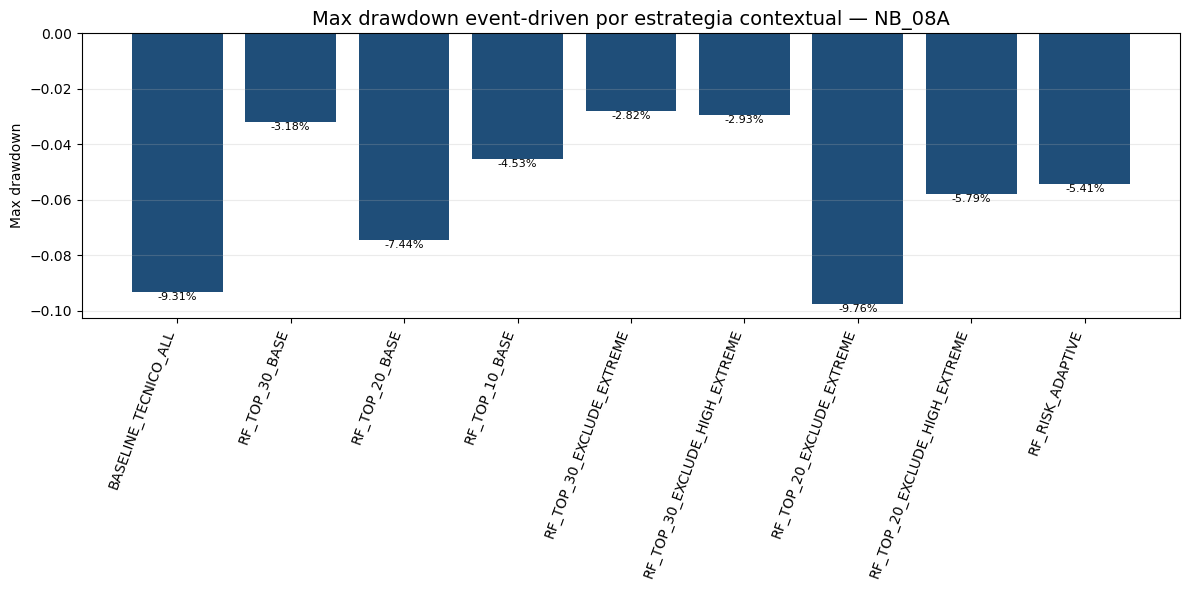

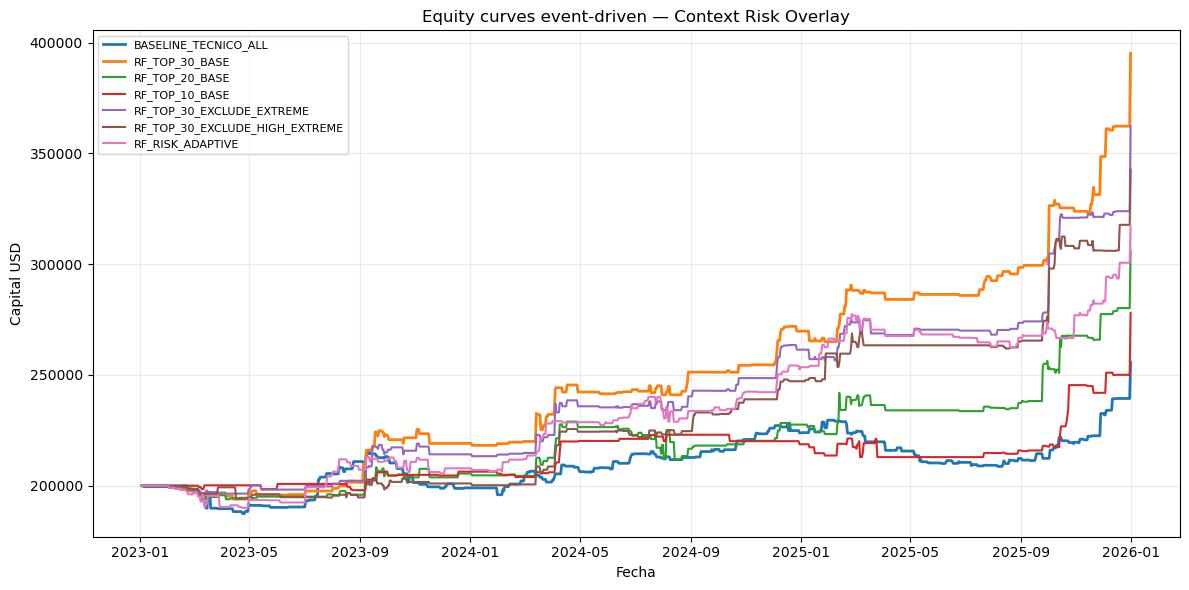

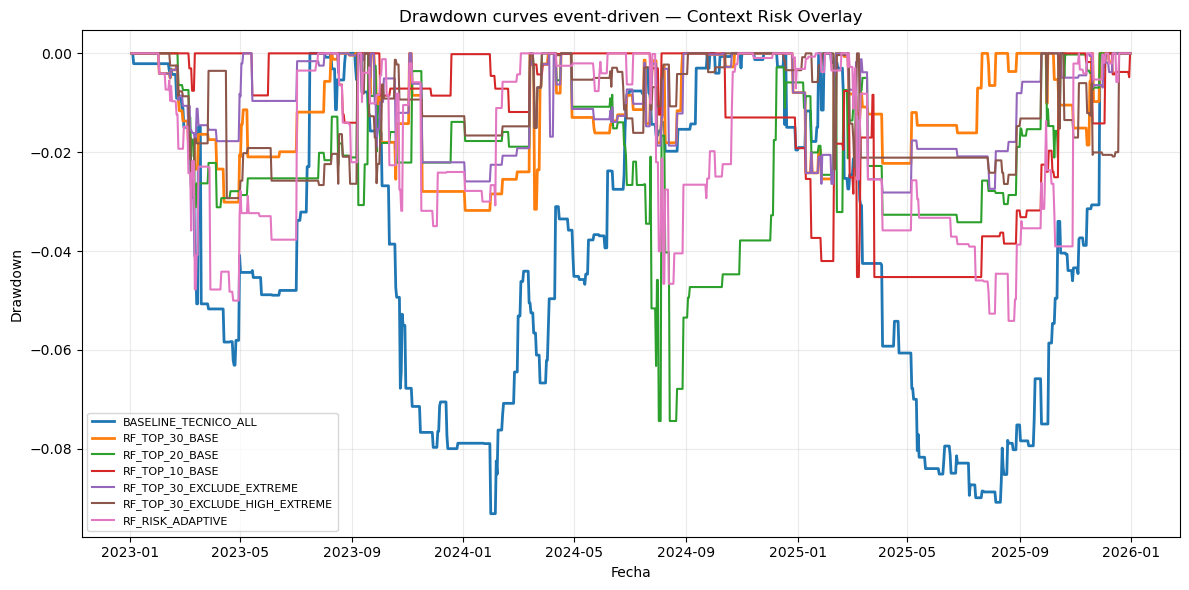

In [12]:
# ============================================================
# 11. Gráficos
# ============================================================

DARK_BLUE = "#1f4e79"
MID_BLUE = "#5b9bd5"
GREY = "#606060"
GREEN = "#70ad47"
RED = "#c00000"

# 1. Bucket risk vs signal quality
plt.figure(figsize=(9, 5))
plot_df = risk_bucket_metrics.copy()
plt.bar(plot_df["context_risk_bucket"].astype(str), plot_df["mean_return"], color=DARK_BLUE)
plt.title("Retorno medio por bucket de riesgo contextual")
plt.ylabel("Retorno medio")
plt.xlabel("Bucket de riesgo")
plt.grid(axis="y", alpha=0.25)
for i, v in enumerate(plot_df["mean_return"]):
    plt.text(i, v, f"{v:.2%}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "mean_return_by_context_risk_bucket_nb08a.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(9, 5))
plt.bar(plot_df["context_risk_bucket"].astype(str), plot_df["success_rate"], color=DARK_BLUE)
plt.title("Success rate por bucket de riesgo contextual")
plt.ylabel("Success rate")
plt.xlabel("Bucket de riesgo")
plt.grid(axis="y", alpha=0.25)
for i, v in enumerate(plot_df["success_rate"]):
    plt.text(i, v, f"{v:.2%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "success_rate_by_context_risk_bucket_nb08a.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()

# 2. Portfolio comparison bars
def bar_metric(df, metric, title, ylabel, filename, pct=False):
    plt.figure(figsize=(12, 6))
    bars = plt.bar(df["strategy"], df[metric], color=DARK_BLUE)
    plt.title(title, fontsize=14)
    plt.ylabel(ylabel)
    plt.xticks(rotation=70, ha="right")
    plt.grid(axis="y", alpha=0.25)
    for b in bars:
        h = b.get_height()
        if pd.notna(h):
            label = f"{h:.2%}" if pct else f"{h:,.0f}"
            plt.text(b.get_x()+b.get_width()/2, h, label, ha="center", va="bottom" if h >= 0 else "top", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

bar_metric(portfolio_metrics, "final_capital", "Capital final por estrategia contextual — NB_08A", "Capital final USD", "final_capital_context_overlay_nb08a.png")
bar_metric(portfolio_metrics, "total_return", "Retorno acumulado por estrategia contextual — NB_08A", "Retorno acumulado", "total_return_context_overlay_nb08a.png", pct=True)
bar_metric(portfolio_metrics, "max_drawdown_event", "Max drawdown event-driven por estrategia contextual — NB_08A", "Max drawdown", "max_drawdown_context_overlay_nb08a.png", pct=True)

# 3. Equity and drawdown curves
key_strategies = [
    "BASELINE_TECNICO_ALL",
    "RF_TOP_30_BASE",
    "RF_TOP_20_BASE",
    "RF_TOP_10_BASE",
    "RF_TOP_30_EXCLUDE_EXTREME",
    "RF_TOP_30_EXCLUDE_HIGH_EXTREME",
    "RF_RISK_ADAPTIVE",
]

if not portfolio_equity.empty:
    eq = portfolio_equity.copy()
    eq["date"] = pd.to_datetime(eq["date"])

    idx = pd.date_range(eq["date"].min(), eq["date"].max(), freq="D")
    equity_panel = []

    plt.figure(figsize=(12, 6))
    for strategy in key_strategies:
        sub = eq[eq["strategy"] == strategy].sort_values("date")
        if sub.empty:
            continue
        s = sub.groupby("date")["equity"].last().reindex(idx).ffill().fillna(INITIAL_CAPITAL)
        equity_panel.append(pd.DataFrame({"date": idx, "strategy": strategy, "equity": s.values}))
        plt.plot(idx, s.values, label=strategy, linewidth=2 if strategy in ["BASELINE_TECNICO_ALL", "RF_TOP_30_BASE"] else 1.5)

    plt.title("Equity curves event-driven — Context Risk Overlay")
    plt.ylabel("Capital USD")
    plt.xlabel("Fecha")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(EQUITY_DIR / "equity_curves_context_overlay_nb08a.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    equity_panel = pd.concat(equity_panel, ignore_index=True)
    equity_panel.to_csv(OUTPUT_DIR / "equity_panel_context_overlay_nb08a.csv", index=False)

    dd_panel = []
    plt.figure(figsize=(12, 6))
    for strategy in key_strategies:
        sub = equity_panel[equity_panel["strategy"] == strategy].copy()
        if sub.empty:
            continue
        sub["drawdown"] = sub["equity"] / sub["equity"].cummax() - 1
        dd_panel.append(sub)
        plt.plot(sub["date"], sub["drawdown"], label=strategy, linewidth=2 if strategy in ["BASELINE_TECNICO_ALL", "RF_TOP_30_BASE"] else 1.5)

    plt.title("Drawdown curves event-driven — Context Risk Overlay")
    plt.ylabel("Drawdown")
    plt.xlabel("Fecha")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(DRAWDOWN_DIR / "drawdown_curves_context_overlay_nb08a.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    dd_panel = pd.concat(dd_panel, ignore_index=True)
    dd_panel.to_csv(OUTPUT_DIR / "drawdown_panel_context_overlay_nb08a.csv", index=False)

## 11. Interpretación preliminar automática

La interpretación final debe validarse revisando outputs.  
El objetivo es evitar conclusiones forzadas.

In [13]:
# ============================================================
# 12. Interpretación preliminar
# ============================================================

best_return = portfolio_metrics.sort_values("final_capital", ascending=False).iloc[0]
best_drawdown = portfolio_metrics.sort_values("max_drawdown_event", ascending=False).iloc[0]

rf_base = portfolio_metrics[portfolio_metrics["strategy"] == "RF_TOP_30_BASE"]
rf_base_text = ""
if not rf_base.empty:
    rf_base = rf_base.iloc[0]
    rf_base_text = f"""
## Referencia RF_TOP_30_BASE
- Capital final: {rf_base['final_capital']:,.2f} USD.
- Retorno acumulado: {rf_base['total_return']:.2%}.
- Max drawdown: {rf_base['max_drawdown_event']:.2%}.
- Trades ejecutados: {int(rf_base['entered_trades'])}.
"""

interpretation = f"""# Interpretación preliminar NB_08A — Context Risk Overlay

## Objetivo
Evaluar si un filtro contextual de riesgo basado en variables de régimen mejora o protege la estrategia técnica + ML.

## Baseline técnico
- Capital final: {baseline['final_capital']:,.2f} USD.
- Retorno acumulado: {baseline['total_return']:.2%}.
- Max drawdown: {baseline['max_drawdown_event']:.2%}.
- Trades ejecutados: {int(baseline['entered_trades'])}.

{rf_base_text}

## Mejor estrategia por capital final
- Estrategia: {best_return['strategy']}.
- Capital final: {best_return['final_capital']:,.2f} USD.
- Retorno acumulado: {best_return['total_return']:.2%}.
- Max drawdown: {best_return['max_drawdown_event']:.2%}.
- Delta capital vs baseline técnico: {best_return['delta_final_capital_vs_baseline']:,.2f} USD.

## Estrategia con menor drawdown
- Estrategia: {best_drawdown['strategy']}.
- Max drawdown: {best_drawdown['max_drawdown_event']:.2%}.
- Capital final: {best_drawdown['final_capital']:,.2f} USD.

## Lectura metodológica preliminar
El Context Risk Overlay no pretende predecir noticias individuales. Evalúa si las variables agregadas de régimen, volatilidad, retorno de mercado y amplitud técnica permiten modular la exposición del sistema.

Si las estrategias con exclusión de riesgo alto/extremo reducen drawdown sin destruir retorno, la capa contextual puede defenderse como una extensión de gestión de riesgo.
Si no mejoran, se debe mantener como análisis exploratorio y no como componente decisorio del MVP final.

## Relación con FinBERT
FinBERT permanece como componente contextual exploratorio. Este notebook prueba primero una aproximación más controlada y trazable: medir el contexto ya reflejado en variables de mercado.
"""

print(interpretation)

with open(OUTPUT_DIR / "interpretacion_preliminar_nb08a.md", "w", encoding="utf-8") as f:
    f.write(interpretation)

# Interpretación preliminar NB_08A — Context Risk Overlay

## Objetivo
Evaluar si un filtro contextual de riesgo basado en variables de régimen mejora o protege la estrategia técnica + ML.

## Baseline técnico
- Capital final: 255,653.88 USD.
- Retorno acumulado: 27.83%.
- Max drawdown: -9.31%.
- Trades ejecutados: 332.


## Referencia RF_TOP_30_BASE
- Capital final: 395,127.30 USD.
- Retorno acumulado: 97.56%.
- Max drawdown: -3.18%.
- Trades ejecutados: 218.


## Mejor estrategia por capital final
- Estrategia: RF_TOP_30_BASE.
- Capital final: 395,127.30 USD.
- Retorno acumulado: 97.56%.
- Max drawdown: -3.18%.
- Delta capital vs baseline técnico: 139,473.42 USD.

## Estrategia con menor drawdown
- Estrategia: RF_TOP_30_EXCLUDE_EXTREME.
- Max drawdown: -2.82%.
- Capital final: 362,180.25 USD.

## Lectura metodológica preliminar
El Context Risk Overlay no pretende predecir noticias individuales. Evalúa si las variables agregadas de régimen, volatilidad, retorno de mercado y amplitud t

In [14]:
# ============================================================
# 13. Listado de outputs
# ============================================================

print("Outputs generados en:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print("-", p.relative_to(OUTPUT_DIR))

Outputs generados en: /Users/rbr/TFM_MVP/JUNIO/NB_08A/outputs_nb08a
- drawdown_panel_context_overlay_nb08a.csv
- equity_panel_context_overlay_nb08a.csv
- figures/drawdowns/drawdown_curves_context_overlay_nb08a.png
- figures/equity_curves/equity_curves_context_overlay_nb08a.png
- figures/final_capital_context_overlay_nb08a.png
- figures/max_drawdown_context_overlay_nb08a.png
- figures/mean_return_by_context_risk_bucket_nb08a.png
- figures/success_rate_by_context_risk_bucket_nb08a.png
- figures/total_return_context_overlay_nb08a.png
- interpretacion_preliminar_nb08a.md
- portfolio_context_overlay_equity_nb08a.csv
- portfolio_context_overlay_skipped_nb08a.csv
- portfolio_context_overlay_trades_nb08a.csv
- tables/context_features_descriptive_nb08a.csv
- tables/context_risk_score_nb08a.csv
- tables/portfolio_context_overlay_metrics_nb08a.csv
- tables/risk_bucket_signal_quality_by_year_nb08a.csv
- tables/risk_bucket_signal_quality_nb08a.csv
- tables/signal_level_strategy_metrics_nb08a.csv
- 